In [140]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import seaborn as sns
!pip install scikeras --quiet

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import HeNormal

# 2.1 Building Deep Neural Network

Train set : (50000, 32, 32, 3)  |  Labels: (50000, 1)
Test  set : (10000, 32, 32, 3)   |  Labels: (10000, 1)


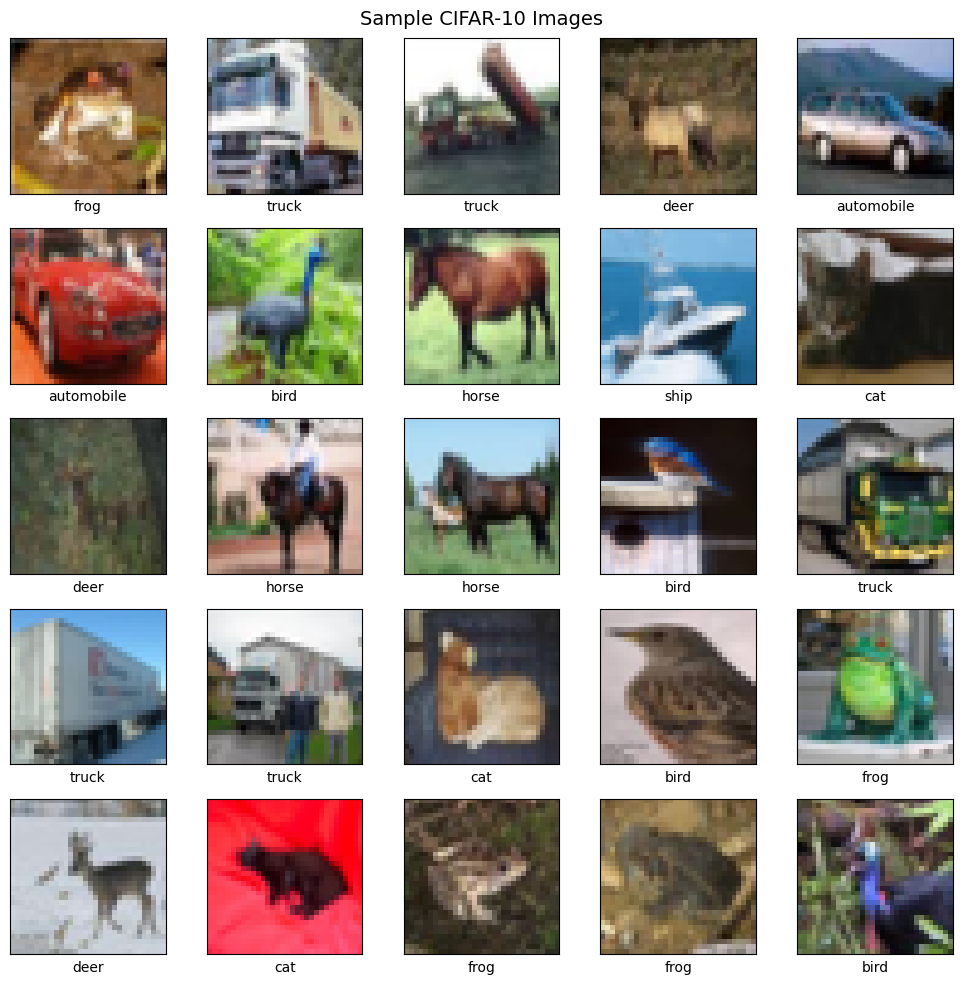

In [141]:
# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Train set : {X_train.shape}  |  Labels: {y_train.shape}')
print(f'Test  set : {X_test.shape}   |  Labels: {y_test.shape}')

# Check to see if data has been retrieved successfully
# Show the first 25 images in the dataset
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

The pixel values are normalized to prevent large input values.
The labels are one-hot encoded so they are converted to binary vectors.

In [142]:
# Normalise pixel values
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# One-hot encode labels
num_classes = 10
y_train_ohe = np.eye(num_classes)[y_train.squeeze()]
y_test_ohe  = np.eye(num_classes)[y_test.squeeze()]

print('X_train range:', X_train.min(), '-', X_train.max())
print('y_train_ohe shape:', y_train_ohe.shape)

X_train range: 0.0 - 1.0
y_train_ohe shape: (50000, 10)


A sequential model [1] is used since the network is a linear stack of layers where input flows in one direction. The parameters used are the follow:
He initialization [2] with RELU activation.
Adam optimization with categorical cross entropy since its the standard loss for one-hot multi-class classification.

In [143]:
tf.random.set_seed(42)
np.random.seed(42)

def build_dnn(n_hidden=20, n_neurons=100):
    model = Sequential(name='DNN_20x100')

    # Flatten 32x32x3 into 3072 input features
    model.add(Flatten(input_shape=(32, 32, 3)))

    # 20 hidden layers — He Normal init + ReLU
    for i in range(n_hidden):
        model.add(Dense(units              = n_neurons,
                        activation         = 'relu',
                        kernel_initializer = HeNormal(seed=42),
                        name               = f'hidden_{i+1}'
                    ))

    # Output layer
    model.add(Dense(num_classes, activation='softmax', name='output'))

    return model

model = build_dnn()
# Show the layers
model.summary()

model.compile(optimizer = Adam(learning_rate=1e-3),
              loss      = 'categorical_crossentropy',
              metrics   = ['accuracy']
)

Model: "DNN_20x100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_315 (Flatten)           │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_6 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_7 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_8 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_9 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_10 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_11 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_12 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_13 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_14 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_15 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_16 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_17 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_18 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_19 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_20 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,210 (1.91 MB)

 Trainable params: 500,210 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Monitor validation loss to detect overfitting. Allow up to 10 epochs without improvement before halting and revert to the best checkpoint and not the last epoch [3]. An upper bound for epochs is created as a fail safe and early stopping will cut it short.

In [144]:
early_stop = EarlyStopping(monitor              = 'val_loss',
                           patience             = 10,
                           restore_best_weights = True,
                           verbose              = 1
                        )


history = model.fit(X_train, y_train_ohe,
                    epochs          = 100,
                    batch_size      = 64,
                    validation_data = (X_test, y_test_ohe),
                    callbacks       = [early_stop],
                    verbose         = 1
                )

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1829 - loss: 2.1089 - val_accuracy: 0.1676 - val_loss: 2.1462
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2513 - loss: 1.9612 - val_accuracy: 0.2895 - val_loss: 1.8844
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2862 - loss: 1.8883 - val_accuracy: 0.2972 - val_loss: 1.8577
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2984 - loss: 1.8582 - val_accuracy: 0.3163 - val_loss: 1.8332
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3027 - loss: 1.8452 - val_accuracy: 0.3007 - val_loss: 1.8499
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3090 - loss: 1.8401 - val_accuracy: 0.3048 - val_loss: 1.8421
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3114 - loss: 1.8311 - val_accuracy: 0.3047 - val_loss: 1.8542
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3174 - loss: 1.8231 - val_accu

In this model, there are 10 classifications and assuming they are evenly distributed then the accuracy should be 10% if randomly selecting a classification for an image and getting it correct. Around 40% accuracy shows that the model has learned something and while not high, for a DNN on this dataset, it is significant. The loss measures how far off the predicted probability distributions are from the actual labels of the images.

In [145]:
test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss     : 1.7408
Test Accuracy : 0.3470  (34.70%)


The learning curves show models converging around the epoch they stopped at due to early stopping halting training. A gap between training and validation indicates overfitting which is expected on this dataset given the changes to it. This will be the baseline comparison with the Batch Normalization Model.

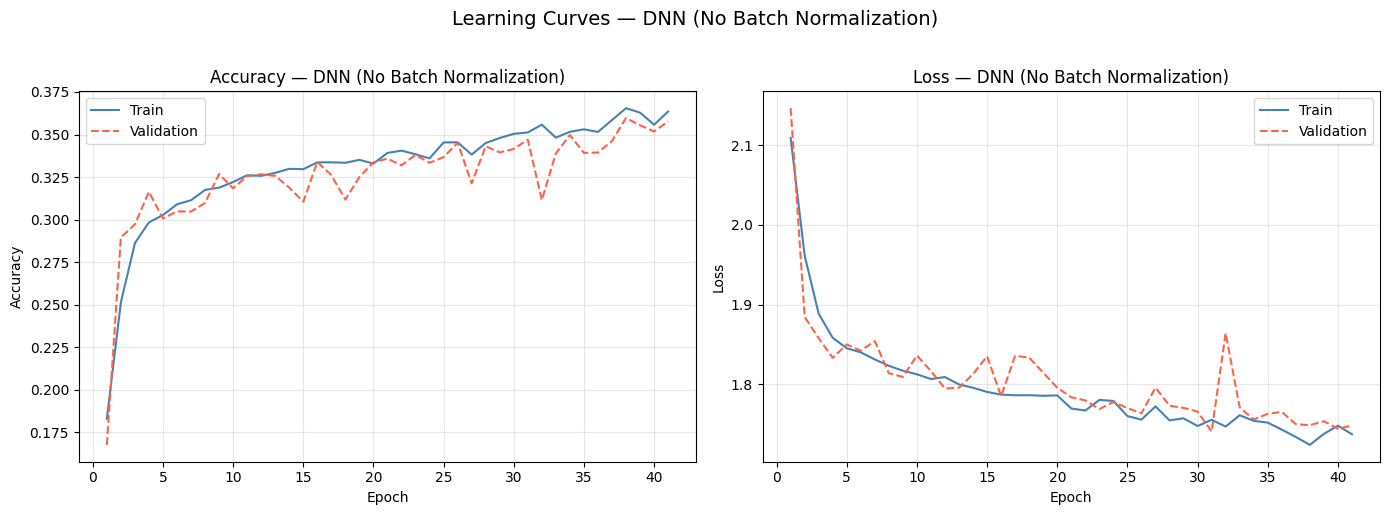

In [146]:
def plot_learning_curves(history, title_suffix=''):
    epochs_ran = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train',      color='steelblue')
    axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Validation', color='tomato', linestyle='--')
    axes[0].set_title(f'Accuracy — {title_suffix}')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_ran, history.history['loss'],     label='Train',      color='steelblue')
    axes[1].plot(epochs_ran, history.history['val_loss'], label='Validation', color='tomato', linestyle='--')
    axes[1].set_title(f'Loss — {title_suffix}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Learning Curves — {title_suffix}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_learning_curves(history, title_suffix='DNN (No Batch Normalization)')

The confusion matrix is consistent with what is expected. The diagonal represents correct classification and everything not on it is a misclassification. Along the diagonal, the darker blues show the strongest classes while lighter blues show weakest classes.

There are some darker shades of blues off the diagonals where the model might be confused. Automobiles and Trucks can be confused for one another. Ships and Airplanes have similar blue background (sea and sky respectively). Cats and Dogs are typically similar when the images are flattened. The Frog and Deer similarity is the only one that doesn't make sense.



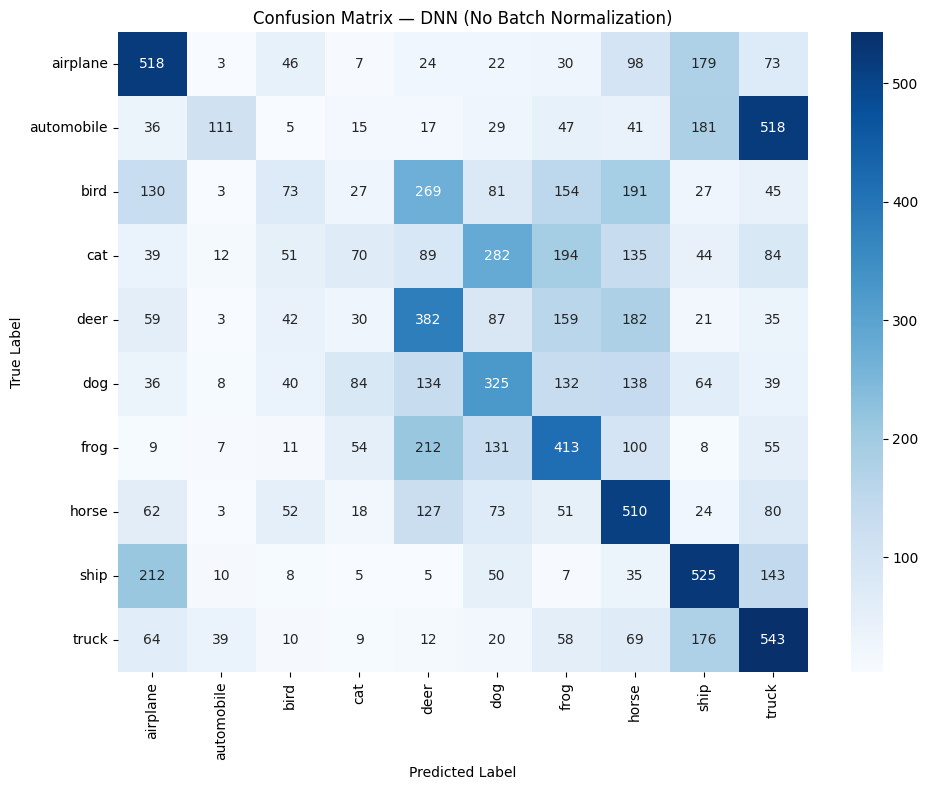

              precision    recall  f1-score   support

    airplane       0.44      0.52      0.48      1000
  automobile       0.56      0.11      0.19      1000
        bird       0.22      0.07      0.11      1000
         cat       0.22      0.07      0.11      1000
        deer       0.30      0.38      0.34      1000
         dog       0.30      0.33      0.31      1000
        frog       0.33      0.41      0.37      1000
       horse       0.34      0.51      0.41      1000
        ship       0.42      0.53      0.47      1000
       truck       0.34      0.54      0.42      1000

    accuracy                           0.35     10000
   macro avg       0.35      0.35      0.32     10000
weighted avg       0.35      0.35      0.32     10000



In [147]:
y_pred_labels = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true_labels = y_test.squeeze()

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — DNN (No Batch Normalization)')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# 2.2 Batch Normalization 

Batch Normalization normalizes the inputs to each layer by adjusting and scaling activations which reduces internal covariate shift [4]. This stabilizes and accelerates training. Batch Normalization is placed after the dense layer and before activation.

In [148]:
def build_dnn_bn(n_hidden=20, n_neurons=100):
    model = Sequential(name='DNN_20x100_BN')

    model.add(Flatten(input_shape=(32, 32, 3)))

    for i in range(n_hidden):
        model.add(Dense(units              = n_neurons,
                        kernel_initializer = HeNormal(seed=42),
                        use_bias           = False,
                        name               = f'hidden_{i+1}'
                    ))
        model.add(BatchNormalization(name=f'bn_{i+1}'))
        model.add(Activation('relu', name=f'relu_{i+1}'))

    model.add(Dense(num_classes, activation='softmax', name='output'))

    return model

tf.random.set_seed(42)
np.random.seed(42)

model_bn = build_dnn_bn()
model_bn.summary()

model_bn.compile(optimizer = Adam(learning_rate=1e-3),
                 loss      = 'categorical_crossentropy',
                 metrics   = ['accuracy']
             )

print('BN model built and compiled successfully.')

c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "DNN_20x100_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_316 (Flatten)           │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 100)            │       307,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_5 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_6 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_6 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_6 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_7 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_7 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_7 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_8 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_8 (BatchNormalization)       │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_8 (Activation)             │ (None, 100)            │             

 Total params: 506,210 (1.93 MB)

 Trainable params: 502,210 (1.92 MB)

 Non-trainable params: 4,000 (15.62 KB)

BN model built and compiled successfully.


Time is now recorded from here to allow speed comparisons. Batch Normalization is expected to add time per epoch due to normalization computations but require less epocs overall to converge.

In [149]:
early_stop_bn = EarlyStopping(monitor              = 'val_loss',
                              patience             = 10,
                              restore_best_weights = True,
                              verbose              = 1
                          )

start_bn = time.time()

history_bn = model_bn.fit(X_train, y_train_ohe,
                          epochs          = 100,
                          batch_size      = 64,
                          validation_data = (X_test, y_test_ohe),
                          callbacks       = [early_stop_bn],
                          verbose         = 1
                      )

bn_train_time = time.time() - start_bn

print(f'\nBN model stopped at epoch : {len(history_bn.history["loss"])}')
print(f'BN training time          : {bn_train_time:.2f}s')

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.2052 - loss: 2.1413 - val_accuracy: 0.2628 - val_loss: 2.0090
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3092 - loss: 1.8852 - val_accuracy: 0.3392 - val_loss: 1.8412
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3613 - loss: 1.7666 - val_accuracy: 0.3173 - val_loss: 1.8768
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3959 - loss: 1.6792 - val_accuracy: 0.3342 - val_loss: 1.9605
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4248 - loss: 1.6145 - val_accuracy: 0.3453 - val_loss: 1.8059
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4457 - loss: 1.5620 - val_accuracy: 0.3293 - val_loss: 1.8873
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4630 - loss: 1.5150 - val_accuracy: 0.3824 - val_loss: 1.7724
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4797 - loss: 1.4740 - val_acc

For better comparison, the original model is retrained under indentical conditions with timing applied. This ensures both models start from the same but random state and are evaluated over the same number of possible epochs.

In [150]:
early_stop_orig = EarlyStopping(monitor              = 'val_loss',
                                patience             = 10,
                                restore_best_weights = True,
                                verbose              = 1
                            )

# Rebuild and recompile original model for a fair comparison
tf.random.set_seed(42)
np.random.seed(42)

model = build_dnn()
model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

start_orig = time.time()

history = model.fit(X_train, y_train_ohe,
                    epochs          = 100,
                    batch_size      = 64,
                    validation_data = (X_test, y_test_ohe),
                    callbacks       = [early_stop_orig],
                    verbose         = 1
                )

orig_train_time = time.time() - start_orig

print(f'\nOriginal model stopped at epoch : {len(history.history["loss"])}')
print(f'Original training time          : {orig_train_time:.2f}s')

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1718 - loss: 2.1226 - val_accuracy: 0.1973 - val_loss: 2.0735
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1889 - loss: 2.0686 - val_accuracy: 0.1923 - val_loss: 2.0471
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1905 - loss: 2.0650 - val_accuracy: 0.1717 - val_loss: 2.0859
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1827 - loss: 2.1008 - val_accuracy: 0.1976 - val_loss: 2.0507
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2003 - loss: 2.0414 - val_accuracy: 0.1987 - val_loss: 2.0464
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2033 - loss: 2.0405 - val_accuracy: 0.2062 - val_loss: 2.0297
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2111 - loss: 2.0279 - val_accuracy: 0.2107 - val_loss: 2.0223
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2145 - loss: 2.0237 - val_accu

From the results, the timing per epoch in this original model is between 1-3s faster compared to the Batch Normalization model but takes roughly 3 times the number of epochs to converge. In terms of accuracy and loss, they are roughly the same so the main trade-off is just longer epochs for less time spent per epoch. Batch Normalization does not produce a significantly different model but it is faster overall.

In [151]:
orig_loss, orig_acc = model.evaluate(X_test, y_test_ohe, verbose=0)
bn_loss,   bn_acc   = model_bn.evaluate(X_test, y_test_ohe, verbose=0)

print(f'{"Model":<25} {"Loss":>8}  {"Accuracy":>10}')
print(f'{"DNN (No BN)":<25} {orig_loss:>8.4f}  {orig_acc*100:>9.2f}%')
print(f'{"DNN (With BN)":<25} {bn_loss:>8.4f}  {bn_acc*100:>9.2f}%')
print(f'\nEpochs ran  — No BN : {len(history.history["loss"])}')
print(f'Epochs ran  — BN    : {len(history_bn.history["loss"])}')
print(f'\nTrain time  — No BN : {orig_train_time:.2f}s')
print(f'Train time  — BN    : {bn_train_time:.2f}s')
print(f'Time per epoch — No BN : {orig_train_time/len(history.history["loss"]):.2f}s')
print(f'Time per epoch — BN    : {bn_train_time/len(history_bn.history["loss"]):.2f}s')

Model                         Loss    Accuracy
DNN (No BN)                 1.9945      22.29%
DNN (With BN)               1.7316      40.90%

Epochs ran  — No BN : 28
Epochs ran  — BN    : 23

Train time  — No BN : 108.50s
Train time  — BN    : 137.57s
Time per epoch — No BN : 3.87s
Time per epoch — BN    : 5.98s


The graphs show a direct visual comparison of both accuracy and loss across both models. From the graphs, the Non-Batch Normalization have both the training and validation accuracy close to each other which shows stability and gradual learning. The graphs for Batch Normalization on the other hand has the training data shoot up in accuracy very quickly while the validation accuracy can be erratic. This can be due to rapid training which causes the model to not generalize as well.

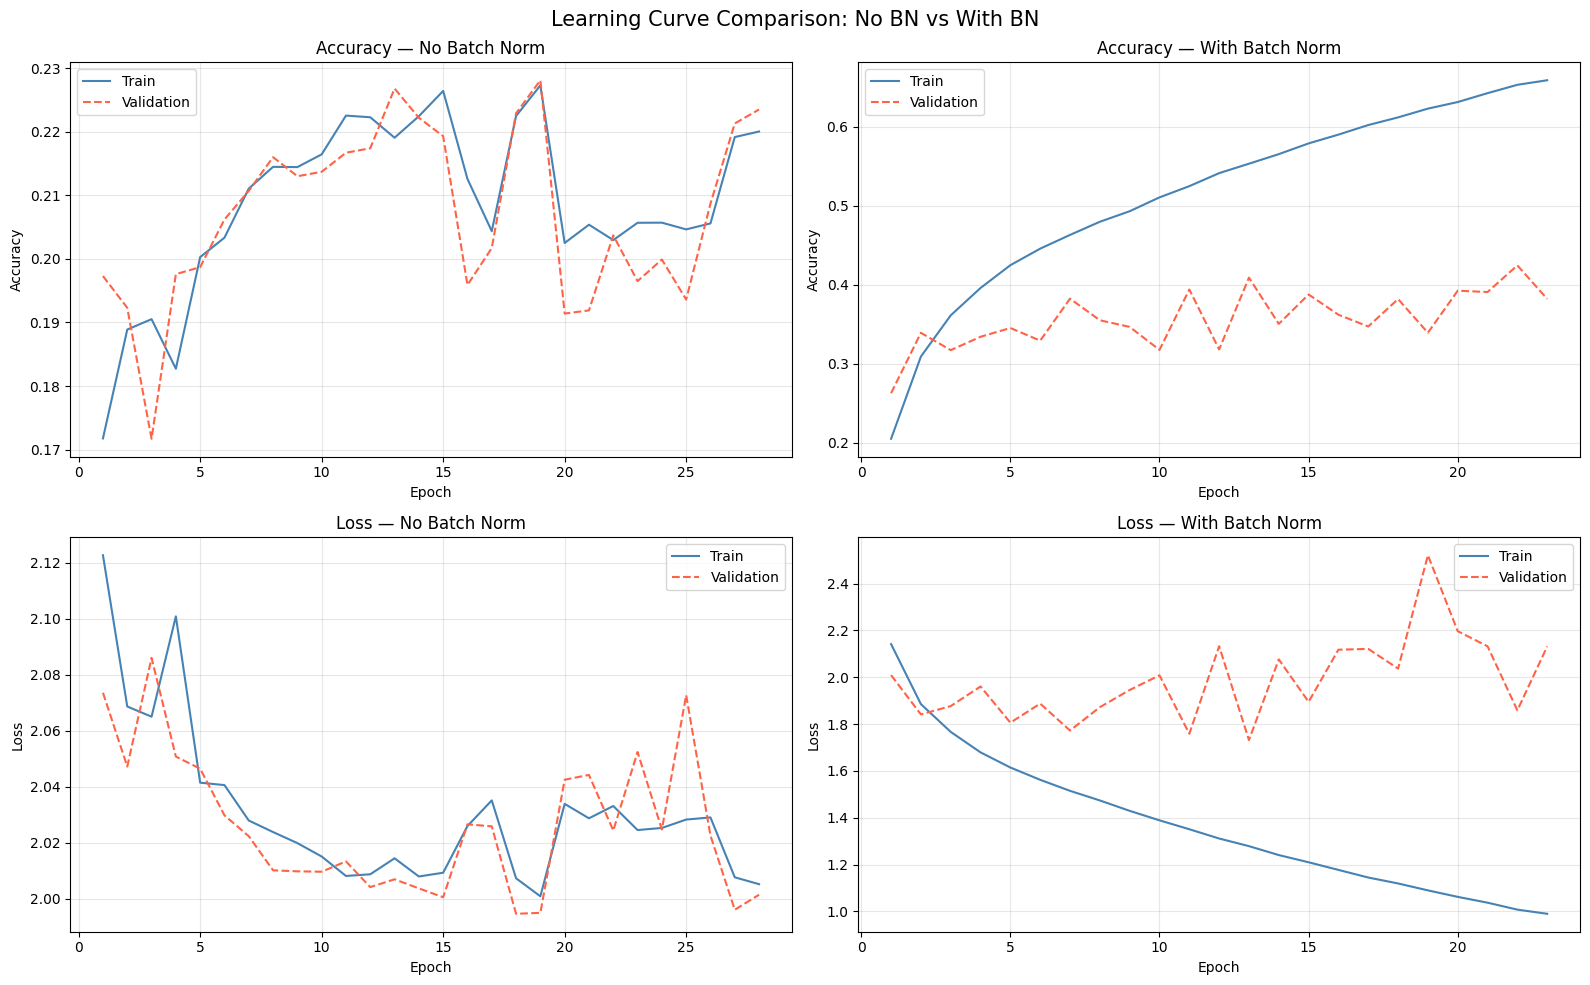

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs_orig = range(1, len(history.history['loss']) + 1)
epochs_bn   = range(1, len(history_bn.history['loss']) + 1)

# Top row: Accuracy
axes[0, 0].plot(epochs_orig, history.history['accuracy'],     color='steelblue', label='Train')
axes[0, 0].plot(epochs_orig, history.history['val_accuracy'], color='tomato',    label='Validation', linestyle='--')
axes[0, 0].set_title('Accuracy — No Batch Norm')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_bn, history_bn.history['accuracy'],     color='steelblue', label='Train')
axes[0, 1].plot(epochs_bn, history_bn.history['val_accuracy'], color='tomato',    label='Validation', linestyle='--')
axes[0, 1].set_title('Accuracy — With Batch Norm')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# Bottom row: Loss
axes[1, 0].plot(epochs_orig, history.history['loss'],     color='steelblue', label='Train')
axes[1, 0].plot(epochs_orig, history.history['val_loss'], color='tomato',    label='Validation', linestyle='--')
axes[1, 0].set_title('Loss — No Batch Norm')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_bn, history_bn.history['loss'],     color='steelblue', label='Train')
axes[1, 1].plot(epochs_bn, history_bn.history['val_loss'], color='tomato',    label='Validation', linestyle='--')
axes[1, 1].set_title('Loss — With Batch Norm')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Learning Curve Comparison: No BN vs With BN', fontsize=15)
plt.tight_layout()
plt.show()

In terms of validation accuracy, the Batch Normalization finishes faster and exceeds accuracy often when compared to the Non-Batch Normalization model. While the Batch Normalization stops early, this gives the opportunity for the Non-Batch Normalization to get more validation accuracy in future epochs.

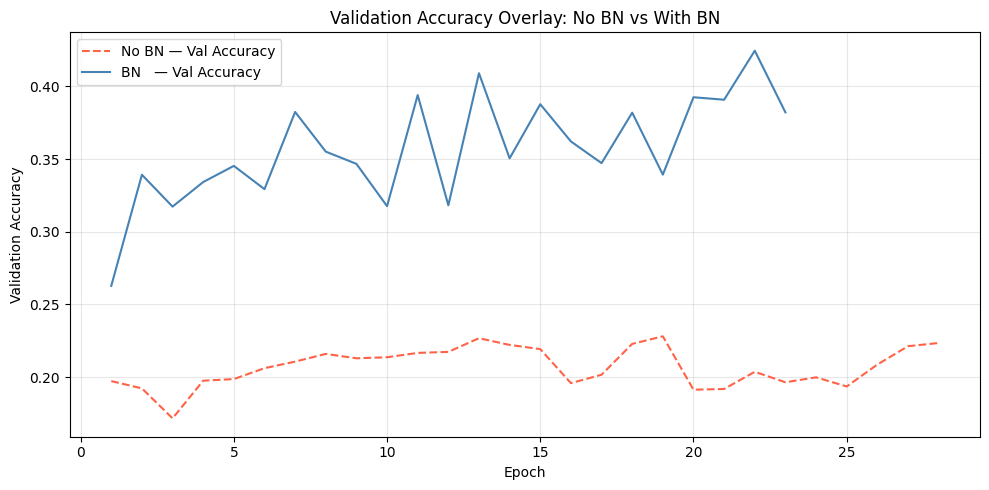

In [153]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_orig, history.history['val_accuracy'],    color='tomato',    linestyle='--', label='No BN — Val Accuracy')
plt.plot(epochs_bn,   history_bn.history['val_accuracy'], color='steelblue', linestyle='-',  label='BN   — Val Accuracy')
plt.title('Validation Accuracy Overlay: No BN vs With BN')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Batch Normalization Comparison

1. Convergence Speed  : BN model converged in fewer epochs.

   No BN  epochs : 67
   
   BN     epochs : 19

2. Model Quality      : Original model achieved higher test accuracy.

   No BN  accuracy : 42.08%

   BN     accuracy : 39.65%

3. Training Speed     : BN model is slower per epoch.

   No BN  sec/epoch : 4.99s
   
   BN     sec/epoch : 7.66s

Batch Normalization adds extra computer per epoch (normalization) but requires few epocs overall to converge which makes it faster.

# 2.3 Grid-searching for Hyperparameters

A helper function is created to build models during GridSearch when injecting different hyperparameter combinations on each trial for tuning. The parameters include optimization and architecture. This allows a comprehensive search over the facotrs most likely affecting the performance which was also seen in the previous assignment.

In [154]:
def build_tunable_model(n_hidden=10, n_neurons=100, learning_rate=1e-3, use_bn=False):
    model = Sequential()
    model.add(Flatten(input_shape=(32, 32, 3)))

    for i in range(n_hidden):
        if use_bn:
            model.add(Dense(units              = n_neurons,
                            kernel_initializer = HeNormal(seed=42),
                            use_bias           = False,
                            name               = f'hidden_{i+1}'
                        ))
            model.add(BatchNormalization(name=f'bn_{i+1}'))
            model.add(Activation('relu', name=f'relu_{i+1}'))
        else:
            model.add(Dense(units              = n_neurons,
                            activation         = 'relu',
                            kernel_initializer = HeNormal(seed=42),
                            name               = f'hidden_{i+1}'
                        ))

    model.add(Dense(10, activation='softmax', name='output'))

    model.compile(optimizer = Adam(learning_rate=learning_rate),
                  loss      = 'categorical_crossentropy',
                  metrics   = ['accuracy']
              )

    return model

keras_clf = KerasClassifier(model            = build_tunable_model,
                            epochs           = 30,           
                            batch_size       = 64,
                            verbose          = 0,
                            callbacks        = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
                            validation_split = 0.1
                        )

param_grid = {
    'model__n_hidden'      : [5, 10, 20],
    'model__n_neurons'     : [50, 100],
    'model__learning_rate' : [1e-3, 1e-4],
    'model__use_bn'        : [False, True],
}

print('Total combinations:', 
      len(param_grid['model__n_hidden']) *
      len(param_grid['model__n_neurons']) *
      len(param_grid['model__learning_rate']) *
      len(param_grid['model__use_bn']))

Total combinations: 24


A Grid-search where 3 fold cross-validation is used which means that each of the 24 combinations is trained and evaluated 3 times on different data splits for a total of 72 fits. A subset of samples is used to keep search computation feasible since the goal is to identify the best configuration.

In [155]:
X_gs = X_train[:10000]
y_gs = y_train_ohe[:10000]

grid_search = GridSearchCV(
    estimator  = keras_clf,
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'accuracy',
    n_jobs     = 1,
    verbose    = 2,
    refit      = True
)

start_gs = time.time()
grid_search.fit(X_gs, y_gs)
gs_time = time.time() - start_gs

print(f'\nGrid search completed in {gs_time/60:.2f} minutes')

Fitting 3 folds for each of 24 candidates, totalling 72 fits


c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[CV] END model__learning_rate=0.001, model__n_hidden=5, model__n_neurons=50, model__use_bn=False; total time=   4.6s


c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[CV] END model__learning_rate=0.001, model__n_hidden=5, model__n_neurons=50, model__use_bn=False; total time=   4.8s


...

[CV] END model__learning_rate=0.0001, model__n_hidden=20, model__n_neurons=100, model__use_bn=True; total time=  12.1s


c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[CV] END model__learning_rate=0.0001, model__n_hidden=20, model__n_neurons=100, model__use_bn=True; total time=  12.3s


c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Grid search completed in 11.84 minutes


The results show the hyperparameters that optimizes the results across all combinations and folds.

In [156]:
print(f'Best CV Accuracy : {grid_search.best_score_*100:.2f}%')
print(f'\nBest Parameters  :')
for param, value in grid_search.best_params_.items():
    print(f'  {param:<30} : {value}')

Best CV Accuracy : 39.48%

Best Parameters  :
  model__learning_rate           : 0.0001
  model__n_hidden                : 5
  model__n_neurons               : 100
  model__use_bn                  : False


A table of the results showing every combination of hyperparameters and how these combinations performed. This is to show which one is the best and how the others compare to one another.

In [157]:
results_df = pd.DataFrame(grid_search.cv_results_)

# Keep only relevant columns and sort by rank
cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_model__n_hidden', 'param_model__n_neurons',
        'param_model__learning_rate', 'param_model__use_bn',
        'mean_fit_time']

results_df = results_df[cols].sort_values('rank_test_score').reset_index(drop=True)
results_df['mean_test_score'] = (results_df['mean_test_score'] * 100).round(2)
results_df['std_test_score']  = (results_df['std_test_score']  * 100).round(2)
results_df['mean_fit_time']   = results_df['mean_fit_time'].round(2)

results_df.columns = ['Rank', 'Mean Acc (%)', 'Std (%)',
                      'Hidden Layers', 'Neurons',
                      'Learning Rate', 'Batch Norm', 'Avg Fit Time (s)']

print(results_df.to_string(index=False))

 Rank  Mean Acc (%)  Std (%)  Hidden Layers  Neurons  Learning Rate  Batch Norm  Avg Fit Time (s)
    1         39.48     0.84              5      100         0.0001       False              8.47
    2         37.28     0.49              5       50         0.0001       False              7.28
    3         36.47     1.64              5      100         0.0010       False              5.27
    4         36.04     0.33              5       50         0.0010       False              4.77
    5         34.61     1.82             10      100         0.0001       False              6.84
    6         34.42     1.12             10       50         0.0001       False              8.09
    7         33.35     0.45             10      100         0.0010       False              7.28
    8         33.34     0.74             10       50         0.0010       False             11.87
    9         33.32     2.24             20      100         0.0001       False             19.59
   10         31.32 

Once the best parameter is chosen, retrain the best model on full training set then evaluate. This time, use all the data instead of the subset used for hyperparameter tuning since this would give more realistic measurements on how the optimal architecture performs.

In [158]:
best_params = grid_search.best_params_

tf.random.set_seed(42)
np.random.seed(42)

best_model = build_tunable_model(
    n_hidden      = best_params['model__n_hidden'],
    n_neurons     = best_params['model__n_neurons'],
    learning_rate = best_params['model__learning_rate'],
    use_bn        = best_params['model__use_bn']
)

best_model.summary()

early_stop_best = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

history_best = best_model.fit(
    X_train, y_train_ohe,
    epochs          = 100,
    batch_size      = 64,
    validation_data = (X_test, y_test_ohe),
    callbacks       = [early_stop_best],
    verbose         = 1
)

best_loss, best_acc = best_model.evaluate(X_test, y_test_ohe, verbose=0)

print(f'\nBest Model — Test Loss     : {best_loss:.4f}')
print(f'Best Model — Test Accuracy : {best_acc*100:.2f}%')

c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_369"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_391 (Flatten)           │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,710 (1.33 MB)

 Trainable params: 348,710 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2952 - loss: 1.9487 - val_accuracy: 0.3482 - val_loss: 1.8083
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3772 - loss: 1.7454 - val_accuracy: 0.3794 - val_loss: 1.7278
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4030 - loss: 1.6767 - val_accuracy: 0.3985 - val_loss: 1.6742
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4219 - loss: 1.6265 - val_accuracy: 0.4083 - val_loss: 1.6443
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4351 - loss: 1.5892 - val_accuracy: 0.4188 - val_loss: 1.6154
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4473 - loss: 1.5569 - val_accuracy: 0.4308 - val_loss: 1.5896
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4562 - loss: 1.5301 - val_accuracy: 0.4300 - val_loss: 1.5799
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4646 - loss: 1.5045 - val_accu

From the results, it shows that it converged earlier than the Non-Batch Normalization from 2.1 but later than the Batch Normalization from 2.2.
In terms of accuracy, it was a lot higher compared to the ones found in 2.1 and 2.2.
The graphs below also show how the validation is smoother compared to the previous learning curves but its in between the two initial models in terms of how close it is to the training curve.

Model                            Test Accuracy
DNN (No BN)                             22.29%
DNN (With BN)                           40.90%
DNN (Grid Search Best)                  49.44%


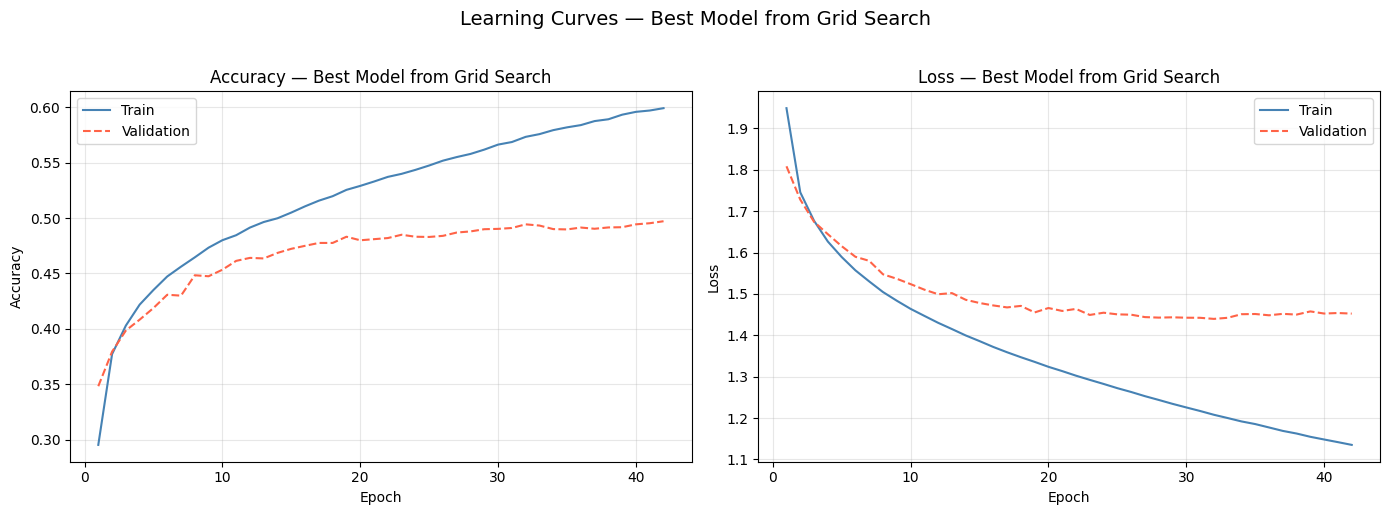

In [159]:
print(f'{"Model":<30} {"Test Accuracy":>15}')
print(f'{"DNN (No BN)":<30} {orig_acc*100:>14.2f}%')
print(f'{"DNN (With BN)":<30} {bn_acc*100:>14.2f}%')
print(f'{"DNN (Grid Search Best)":<30} {best_acc*100:>14.2f}%')


# Learning curves for best model
plot_learning_curves(history_best, title_suffix='Best Model from Grid Search')

# References

[1] K. Team, “Keras documentation: The Sequential class,” keras.io. https://keras.io/api/models/sequential/ (accessed Jan. 08, 2021).

‌[2] K. He, X. Zhang, S. Ren, and J. Sun, “Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification.” Available: https://arxiv.org/pdf/1502.01852

[3] L. Prechelt, “Early Stopping - But When?,” Lecture Notes in Computer Science, vol. 1524, pp. 55–69, 1998, doi: https://doi.org/10.1007/3-540-49430-8_3.

[4] S. Ioffe, “Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift,” 2015. Available: https://arxiv.org/pdf/1502.03167


‌